In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_feat_eng import *
import math 
import datetime

# Novas colunas

In [61]:
df = pd.read_csv('../data/processed_v1/df_clean.csv', sep=';', encoding='utf-8-sig')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21608,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21609,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21610,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [62]:
# Correção do datetime
df_clean = colunas_datetime(df)

In [63]:
df_clean.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno'],
      dtype='object')

In [64]:
df_novascolunas = df_clean.copy()
#-------------------------------------------------------------------------
df_novascolunas['sqft_lot_more_living'] = (df_novascolunas['sqft_living'] + df_novascolunas['sqft_lot']).round(4)
df_novascolunas['living_percent_total'] = (df_novascolunas['sqft_living'] / df_novascolunas['sqft_lot_more_living']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['percent_construcao_above'] = (df_novascolunas['sqft_above']/df_novascolunas['sqft_living']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['lot_15_compare'] =  (df_novascolunas['sqft_lot']/df_novascolunas['sqft_lot15']).round(4)
df_novascolunas['living_15_compare'] = (df_novascolunas['sqft_living']/df_novascolunas['sqft_living15']).round(4)
#-------------------------------------------------------------------------
df_novascolunas['mean_price_zipcode'] = (df_novascolunas.groupby('zipcode')['price'].transform('mean')).round(4)
#-------------------------------------------------------------------------
ano_atual = datetime.datetime.now().year
df_novascolunas['age'] = ano_atual - df_novascolunas['yr_built']
df_novascolunas['age_renovated'] = np.where(
    df_novascolunas['yr_renovated'] == 0, 
    df_novascolunas['age'], 
    ano_atual - df_novascolunas['yr_renovated']
).round(2)
#-------------------------------------------------------------------------
df_novascolunas['bath_per_bed'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bathrooms'] / df_novascolunas['bedrooms']).round(4),
    df_novascolunas['bathrooms'])
df_novascolunas['bed_per_floor'] = np.where(
    df_novascolunas['bedrooms'] > 0,
    (df_novascolunas['bedrooms'] / df_novascolunas['floors']).round(4),
    df_novascolunas['bedrooms'])
#-------------------------------------------------------------------------
df_novascolunas['grade_x_condition'] = df_novascolunas['grade'] * df_novascolunas['condition']
#-------------------------------------------------------------------------
df_novascolunas['bool_renovated'] = np.where(df_novascolunas['yr_renovated'] > 0, 1, 0)
df_novascolunas['bool_basement'] = np.where(df_novascolunas['sqft_basement'] > 0, 1, 0)
df_novascolunas['living_more_than_lot'] = np.where(df_novascolunas['sqft_living'] >= df_novascolunas['sqft_lot'], 1, 0)
#-------------------------------------------------------------------------
# Cidades próximas
seattle_lat, seattle_long = 47.6062, -122.3321
df_novascolunas['dist_seattle'] = np.sqrt(
    (df_novascolunas['lat'] - seattle_lat)**2 + 
    (df_novascolunas['long'] - seattle_long)**2
).round(4)


In [65]:
# Confirmando range
df_novascolunas['age_renovated'].describe()

count    21612.000000
mean        52.612761
std         28.806961
min         11.000000
25%         27.000000
50%         49.000000
75%         72.000000
max        126.000000
Name: age_renovated, dtype: float64

In [66]:
df_novascolunas['bool_renovated_45'] = np.where(df_novascolunas['age_renovated'] < 45, 1, 0)
df_novascolunas['bool_renovated_15'] = np.where(df_novascolunas['age_renovated'] < 15, 1, 0)

In [67]:
df_v1 = df_novascolunas.copy()

In [68]:
Bellevue_lat, Bellevue_long = 47.6101, -122.2015
df_novascolunas['dist_Bellevue'] = np.sqrt(
    (df_novascolunas['lat'] - Bellevue_lat)**2 + 
    (df_novascolunas['long'] - Bellevue_long)**2
).round(4)
Redmond_lat, Redmond_long = 47.6740, -122.1215
df_novascolunas['dist_Redmond'] = np.sqrt(
    (df_novascolunas['lat'] - Redmond_lat)**2 + 
    (df_novascolunas['long'] - Redmond_long)**2
).round(4)
# Pontos turisticos
Snoqualmie_lat, Snoqualmie_long = 47.5417, -121.8373
df_novascolunas['dist_Snoqualmie'] = np.sqrt(
    (df_novascolunas['lat'] - Snoqualmie_lat)**2 + 
    (df_novascolunas['long'] - Snoqualmie_long)**2
).round(4)
Mountdaniel_lat, Mountdaniel_long = 47.5615, -121.1323
df_novascolunas['dist_Mountdaniel'] = np.sqrt(
    (df_novascolunas['lat'] - Mountdaniel_lat)**2 + 
    (df_novascolunas['long'] - Mountdaniel_long)**2
).round(4)
vashonisland_lat, vashonisland_long = 47.4165, -122.4645
df_novascolunas['dist_vashonisland'] = np.sqrt(
    (df_novascolunas['lat'] - vashonisland_lat)**2 + 
    (df_novascolunas['long'] - vashonisland_long)**2
).round(4)
# Infraestrutura
aeroporto_SeaTac_lat, aeroporto_SeaTac_long = 47.4502, -122.3088
df_novascolunas['dist_SeaTac'] = np.sqrt(
    (df_novascolunas['lat'] - aeroporto_SeaTac_lat)**2 + 
    (df_novascolunas['long'] - aeroporto_SeaTac_long)**2
).round(4)

In [69]:
# Multiplicação de colunas relevantes para o modelo
df_novascolunas['waterfront_grade'] = df_novascolunas['waterfront'] * df_novascolunas['grade']
df_novascolunas['living_grade'] = df_novascolunas['sqft_living'] * df_novascolunas['grade']
df_novascolunas['living_waterffront'] = df_novascolunas['sqft_living'] * df_novascolunas['waterfront']
df_novascolunas['waterfront_condition'] = df_novascolunas['waterfront'] * df_novascolunas['condition']
df_novascolunas['luxury'] = df_novascolunas['grade'] * df_novascolunas['mean_price_zipcode']*df_novascolunas['sqft_living']*df_novascolunas['condition']

In [70]:
df_v2 = df_novascolunas.copy()

# 1º Limpeza de colunas

In [71]:
df_novascolunas.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'hora', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'sqft_lot_more_living',
       'living_percent_total', 'percent_construcao_above', 'lot_15_compare',
       'living_15_compare', 'mean_price_zipcode', 'age', 'age_renovated',
       'bath_per_bed', 'bed_per_floor', 'grade_x_condition', 'bool_renovated',
       'bool_basement', 'living_more_than_lot', 'dist_seattle',
       'bool_renovated_45', 'bool_renovated_15', 'dist_Bellevue',
       'dist_Redmond', 'dist_Snoqualmie', 'dist_Mountdaniel',
       'dist_vashonisland', 'dist_SeaTac', 'waterfront_grade', 'living_grad

In [72]:
limpeza_colunas = ['id','yr_built','zipcode','lat','long','hora']


df_v1 = df_v1.drop(columns=limpeza_colunas)
df_v1.to_csv('../data/processed_v1/df_v1.csv', index=False, sep=';', encoding='utf-8-sig')
df_v2 = df_v2.drop(columns=limpeza_colunas)
df_v2.to_csv('../data/processed_v2/df_v2.csv', index=False, sep=';', encoding='utf-8-sig')

# 2º Limpeza (Multicolinearidade)

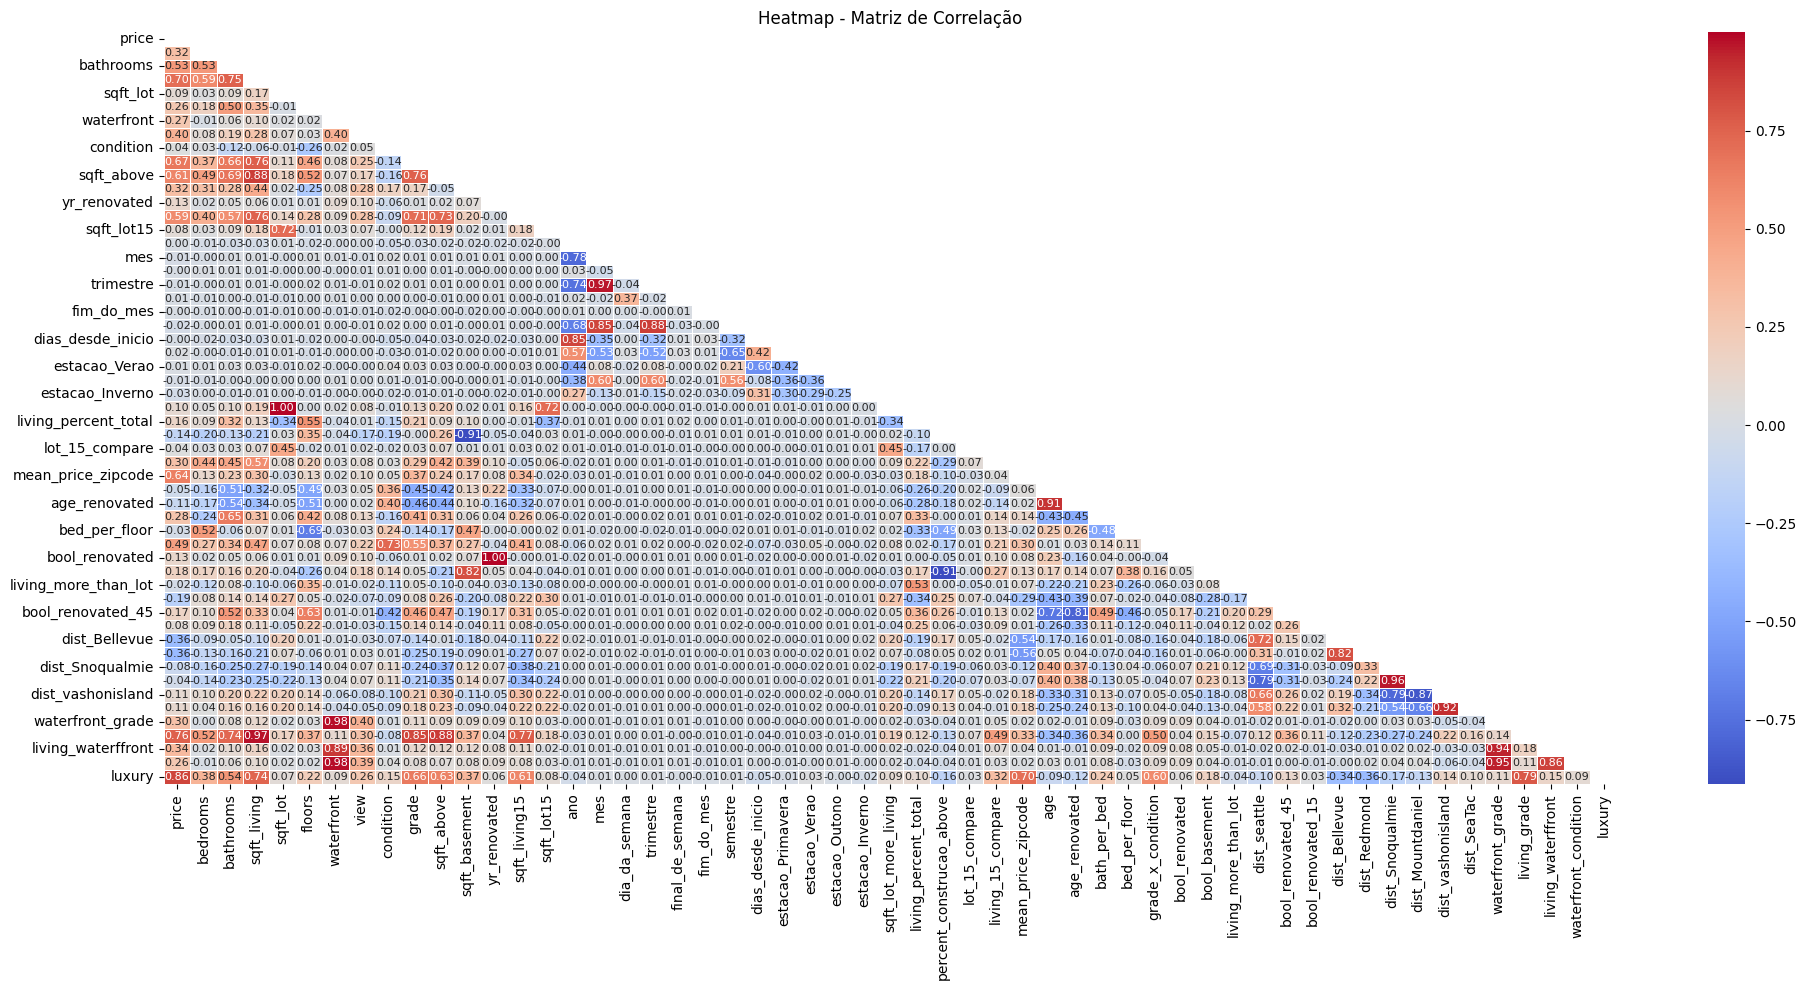

In [73]:
corr = df_v2.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 10))
sns.heatmap(df_v2.corr(), mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,annot_kws={"size": 8})
plt.title('Heatmap - Matriz de Correlação')
plt.tight_layout()
plt.show()

In [74]:
# Tratando multicolinearidade
df_heatmap = df_v2.copy()
lista = ['yr_renovated','bool_basement','percent_construcao_above','sqft_above','sqft_lot_more_living']
df_heatmap = df_heatmap.drop(columns=lista)
df_heatmap.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_basement',
       'sqft_living15', 'sqft_lot15', 'ano', 'mes', 'dia_da_semana',
       'trimestre', 'final_de_semana', 'fim_do_mes', 'semestre',
       'dias_desde_inicio', 'estacao_Primavera', 'estacao_Verao',
       'estacao_Outono', 'estacao_Inverno', 'living_percent_total',
       'lot_15_compare', 'living_15_compare', 'mean_price_zipcode', 'age',
       'age_renovated', 'bath_per_bed', 'bed_per_floor', 'grade_x_condition',
       'bool_renovated', 'living_more_than_lot', 'dist_seattle',
       'bool_renovated_45', 'bool_renovated_15', 'dist_Bellevue',
       'dist_Redmond', 'dist_Snoqualmie', 'dist_Mountdaniel',
       'dist_vashonisland', 'dist_SeaTac', 'waterfront_grade', 'living_grade',
       'living_waterffront', 'waterfront_condition', 'luxury'],
      dtype='object')

In [75]:
criar_painel_diagnostico(df_heatmap)

,Coluna,Assimetria (Skew),Precisa de LOG?,Qtd Outliers,% Outliers,Possível Ruído?,Ação Recomendada
23,estacao_Outono,1.25,Não,5063,23.43,Não,Suavizar Outliers (Capping)
26,lot_15_compare,31.85,SIM,3918,18.13,Não,Aplicar LOG + Suavizar Outliers (Capping)
24,estacao_Inverno,1.75,SIM,3699,17.12,Não,Aplicar LOG + Suavizar Outliers (Capping)
4,sqft_lot,13.06,SIM,2425,11.22,Não,Aplicar LOG + Suavizar Outliers (Capping)
12,sqft_lot15,9.51,SIM,2194,10.15,Não,Aplicar LOG + Suavizar Outliers (Capping)
7,view,3.40,SIM,2124,9.83,Não,Aplicar LOG + Suavizar Outliers (Capping)
9,grade,0.77,Não,1911,8.84,Não,Suavizar Outliers (Capping)
49,luxury,4.87,SIM,1573,7.28,Não,Aplicar LOG + Suavizar Outliers (Capping)
27,living_15_compare,2.03,SIM,1490,6.89,Não,Aplicar LOG + Suavizar Outliers (Capping)
0,price,4.02,SIM,1146,5.30,Não,Aplicar LOG + Suavizar Outliers (Capping)


In [76]:
# Tratamento dos zeros suspeitos
print(df_heatmap.shape)
df_heatmap = df_heatmap[(df_heatmap['bedrooms'] > 0) & (df_heatmap['bathrooms'] > 0)]
print(df_heatmap.shape)

(21612, 50)
(21596, 50)


In [77]:
df_step_1 = df_heatmap.copy()

In [78]:
obter_listas_tratamento(df_step_1)

{'log': ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'waterfront_grade',
  'living_grade',
  'living_waterffront',
  'waterfront_condition',
  'luxury'],
 'capping': ['price',
  'sqft_lot',
  'view',
  'grade',
  'sqft_lot15',
  'estacao_Outono',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'bool_renovated_15',
  'luxury'],
 'extremos': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'waterfront',
  'condition',
  'sqft_basement',
  'sqft_living15',
  'final_de_semana',
  'fim_do_mes',
  'living_percent_total',
  'mean_price_zipcode',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'bool_renovated',
  'living_more_than_lot',
  'dist_seattle',
  'dist_Bellevue',
  'dist_Redmond',
  'dist_Snoqualmie',
  'dist_Mountdaniel',

In [79]:
# Tinha uns valores zero que fui investigar mas foi só colocar mais umas casas decimais
df_heatmap['living_percent_total']

0        0.1728
1        0.2619
2        0.0715
3        0.2816
4        0.1721
          ...  
21607    0.5750
21608    0.2844
21609    0.4304
21610    0.4012
21611    0.4866
Name: living_percent_total, Length: 21596, dtype: float64

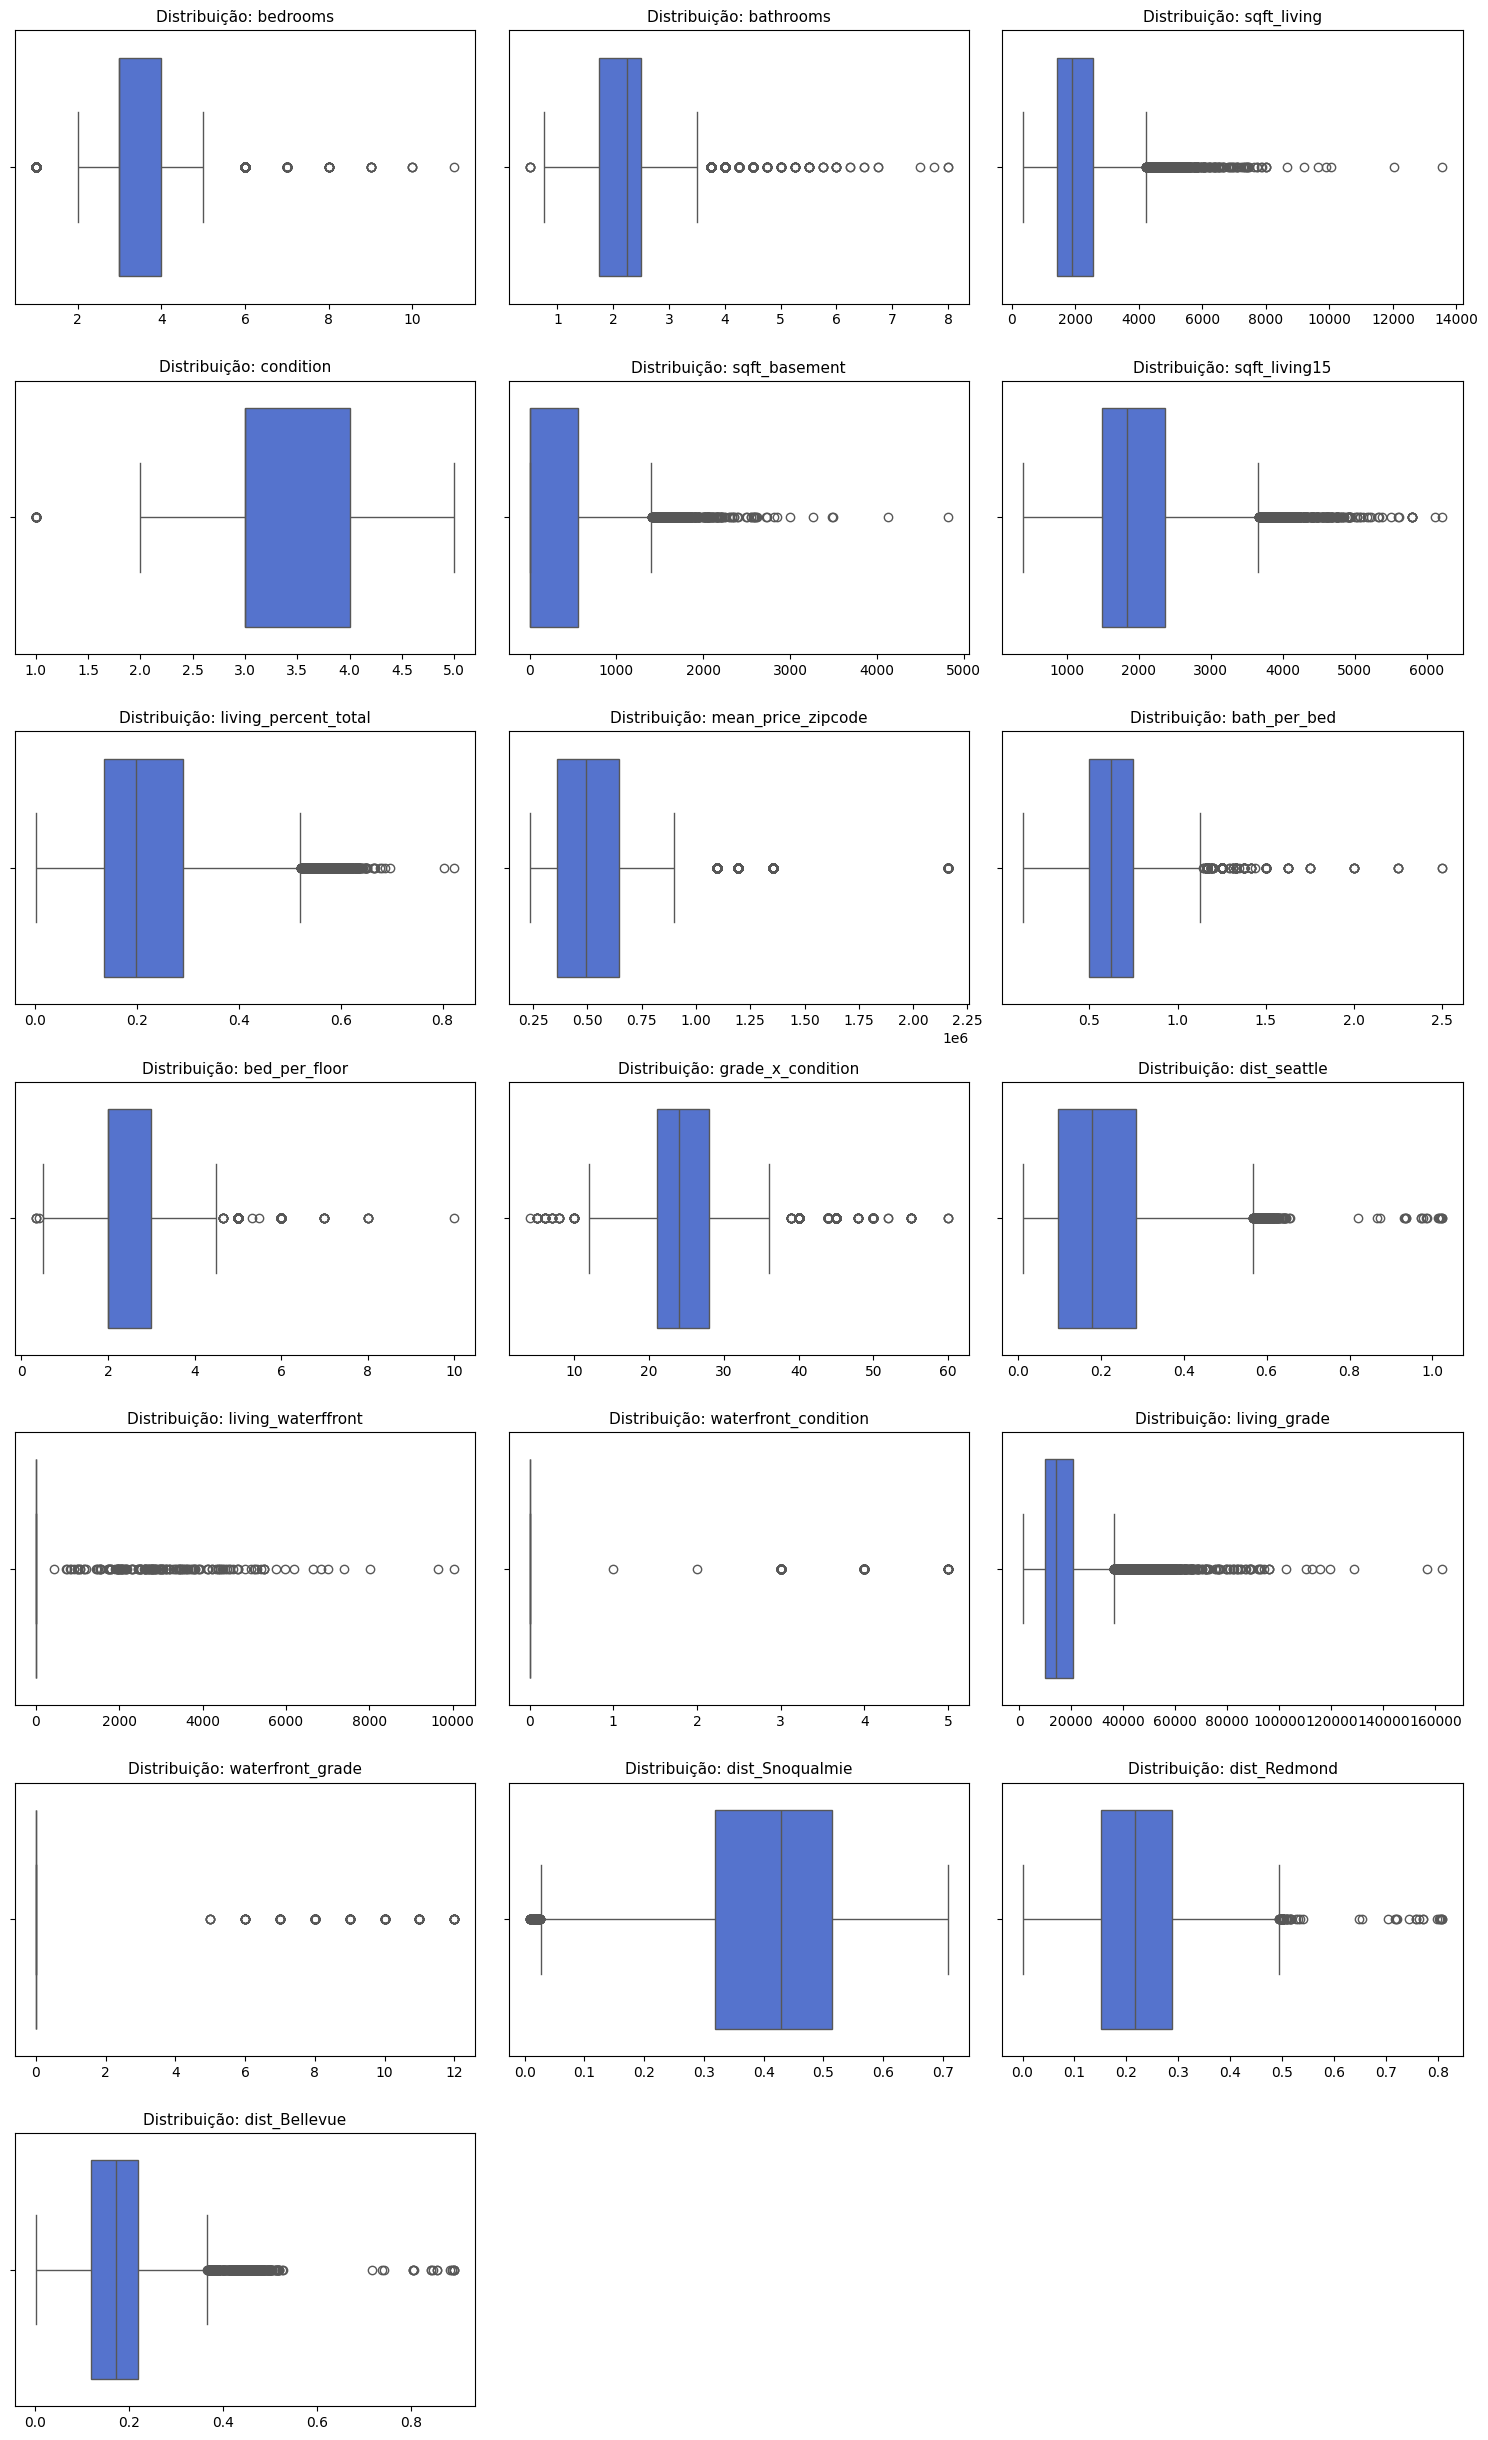

In [80]:
# Conferindo ditribuição geral dos dados e valores extremos

lista_extremos = ['bedrooms',
  'bathrooms',
  'sqft_living',
  'condition',
  'sqft_basement',
  'sqft_living15',
  'living_percent_total',
  'mean_price_zipcode',
  'bath_per_bed',
  'bed_per_floor',
  'grade_x_condition',
  'dist_seattle',
  'living_waterffront',
  'waterfront_condition',
  'living_grade',
  'waterfront_grade',
  'dist_Snoqualmie',
  'dist_Redmond',
  'dist_Bellevue']

cols_por_linha = 3
qtd_linhas = math.ceil(len(lista_extremos) / cols_por_linha)

fig, axes = plt.subplots(qtd_linhas, cols_por_linha, figsize=(15, qtd_linhas * 3.5))
axes = axes.flatten()

for i, col in enumerate(lista_extremos):
    sns.boxplot(x=df_heatmap[col], ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribuição: {col}', fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [81]:
# Confirmando valores extremos
df_heatmap[lista_extremos].describe(percentiles=[0.5, 0.95, 0.99, 0.999]).T[['min', '50%', '95%', '99%', '99.9%', 'max']]

,min,50%,95%,99%,99.9%,max
bedrooms,1.0000,3.0000,5.000000,6.000000e+00,8.000000e+00,1.100000e+01
bathrooms,0.5000,2.2500,3.500000,4.250000e+00,5.500000e+00,8.000000e+00
sqft_living,370.0000,1910.0000,3760.000000,4.980000e+03,7.290250e+03,1.354000e+04
condition,1.0000,3.0000,5.000000,5.000000e+00,5.000000e+00,5.000000e+00
sqft_basement,0.0000,0.0000,1190.000000,1.660000e+03,2.372150e+03,4.820000e+03
sqft_living15,399.0000,1840.0000,3300.000000,4.080000e+03,5.012150e+03,6.210000e+03
living_percent_total,0.0006,0.1985,0.471300,5.766050e-01,6.390645e-01,8.231000e-01
mean_price_zipcode,234284.0352,493552.5321,879623.623900,1.355927e+06,2.160607e+06,2.160607e+06
bath_per_bed,0.1250,0.6250,1.000000,1.250000e+00,1.625000e+00,2.500000e+00
bed_per_floor,0.3333,2.0000,4.000000,5.000000e+00,6.000000e+00,1.000000e+01


In [82]:
# Tratando o Log
colunas_log_sem_bool_v1 = ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15']

colunas_log_sem_bool_v2 = ['price',
  'sqft_lot',
  'waterfront',
  'view',
  'sqft_basement',
  'sqft_lot15',
  'final_de_semana',
  'fim_do_mes',
  'estacao_Inverno',
  'lot_15_compare',
  'living_15_compare',
  'mean_price_zipcode',
  'bool_renovated',
  'living_more_than_lot',
  'bool_renovated_15',
  'waterfront_grade',
  'living_grade',
  'living_waterffront',
  'waterfront_condition',
  'luxury']

for col in colunas_log_sem_bool_v2:
    if df_heatmap[col].nunique() <= 5:
      continue
    else:
      df_heatmap[f'{col}_log'] = np.log1p(df_heatmap[col])
      df_heatmap.drop(columns=[col], inplace=True)

for col in colunas_log_sem_bool_v1:
    if df_v1[col].nunique() <= 5:
      continue
    else:
      df_v1[f'{col}_log'] = np.log1p(df_v1[col])
      df_v1.drop(columns=[col], inplace=True)

In [ ]:
criar_painel_diagnostico(df_heatmap)

,Coluna,Assimetria (Skew),Precisa de LOG?,Qtd Outliers,% Outliers,Possível Ruído?,Ação Recomendada
19,estacao_Outono,1.26,Não,5056,23.41,Não,Suavizar Outliers (Capping)
42,lot_15_compare_log,4.79,SIM,3882,17.98,Não,Aplicar LOG + Suavizar Outliers (Capping)
20,estacao_Inverno,1.75,SIM,3695,17.11,Não,Aplicar LOG + Suavizar Outliers (Capping)
39,sqft_lot_log,0.96,Não,2554,11.83,Não,Suavizar Outliers (Capping)
41,sqft_lot15_log,0.97,Não,2487,11.52,Não,Suavizar Outliers (Capping)
5,view,3.40,SIM,2122,9.83,Não,Aplicar LOG + Suavizar Outliers (Capping)
7,grade,0.79,Não,1905,8.82,Não,Suavizar Outliers (Capping)
43,living_15_compare_log,0.84,Não,1415,6.55,Não,Suavizar Outliers (Capping)
31,bool_renovated_15,4.04,SIM,1123,5.20,Não,Aplicar LOG + Suavizar Outliers (Capping)
27,bool_renovated,4.55,SIM,914,4.23,Não,Aplicar LOG + Checar Extremos


In [85]:
df_v1.to_csv('../data/processed_v1/df_eng_feat_v1.csv', index=False, sep=';', encoding='utf-8-sig')
df_heatmap.to_csv('../data/processed_v2/df_eng_feat_v2.csv', index=False, sep=';', encoding='utf-8-sig')

In [86]:
df_v1.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_above', 'yr_renovated', 'sqft_living15',
       'ano', 'mes', 'dia_da_semana', 'trimestre', 'final_de_semana',
       'fim_do_mes', 'semestre', 'dias_desde_inicio', 'estacao_Primavera',
       'estacao_Verao', 'estacao_Outono', 'estacao_Inverno',
       'sqft_lot_more_living', 'living_percent_total',
       'percent_construcao_above', 'age', 'age_renovated', 'bath_per_bed',
       'bed_per_floor', 'grade_x_condition', 'bool_renovated', 'bool_basement',
       'living_more_than_lot', 'dist_seattle', 'bool_renovated_45',
       'bool_renovated_15', 'price_log', 'sqft_lot_log', 'sqft_basement_log',
       'sqft_lot15_log', 'lot_15_compare_log', 'living_15_compare_log',
       'mean_price_zipcode_log'],
      dtype='object')

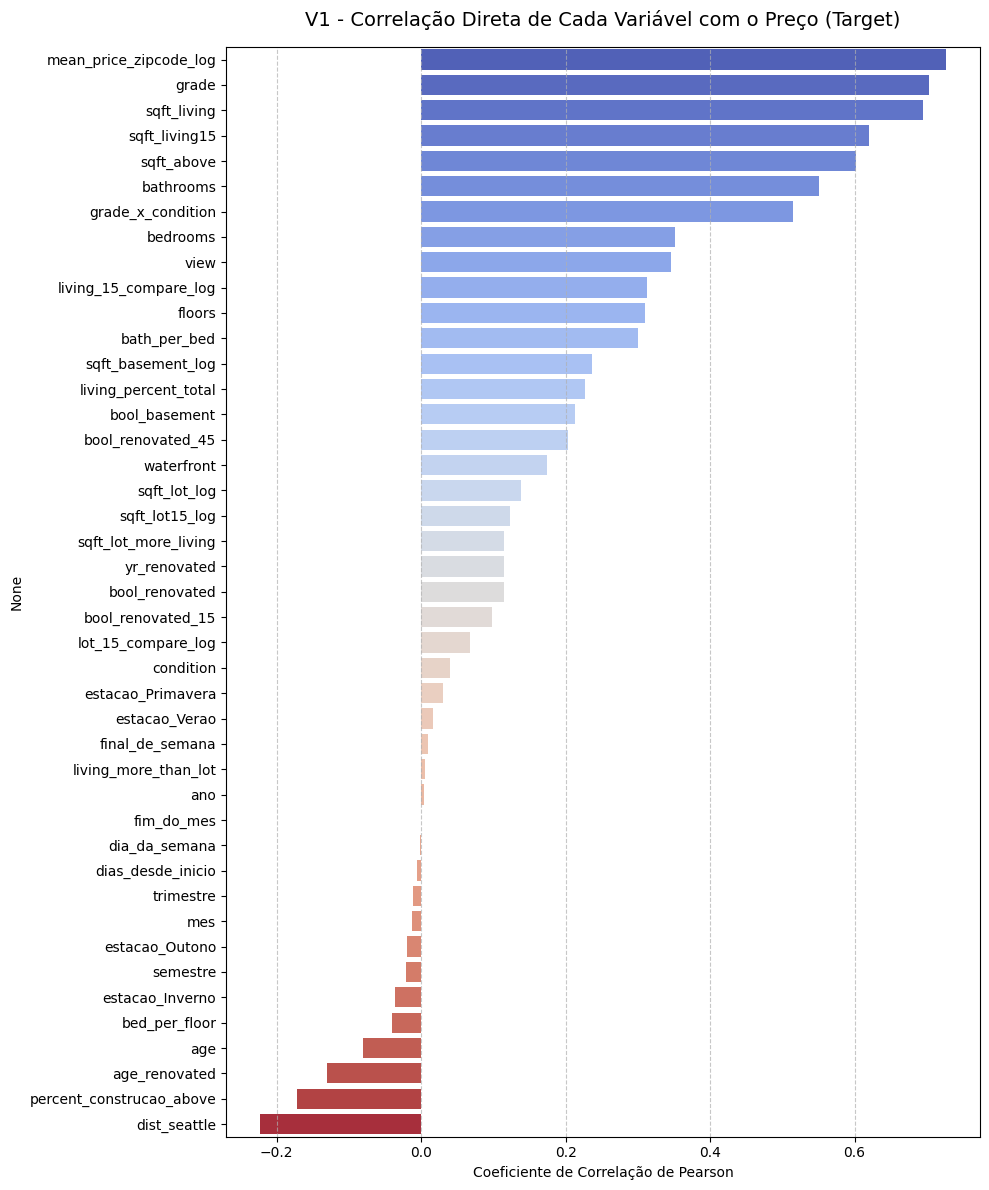

In [87]:
# Correlação V1
price_corr = df_v1.corr()['price_log'].sort_values(ascending=False).drop('price_log')

plt.figure(figsize=(10, 12))

sns.barplot(
    x=price_corr.values, 
    y=price_corr.index, 
    hue=price_corr.index, 
    palette='coolwarm', 
    legend=False
)

plt.title('V1 - Correlação Direta de Cada Variável com o Preço (Target)', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

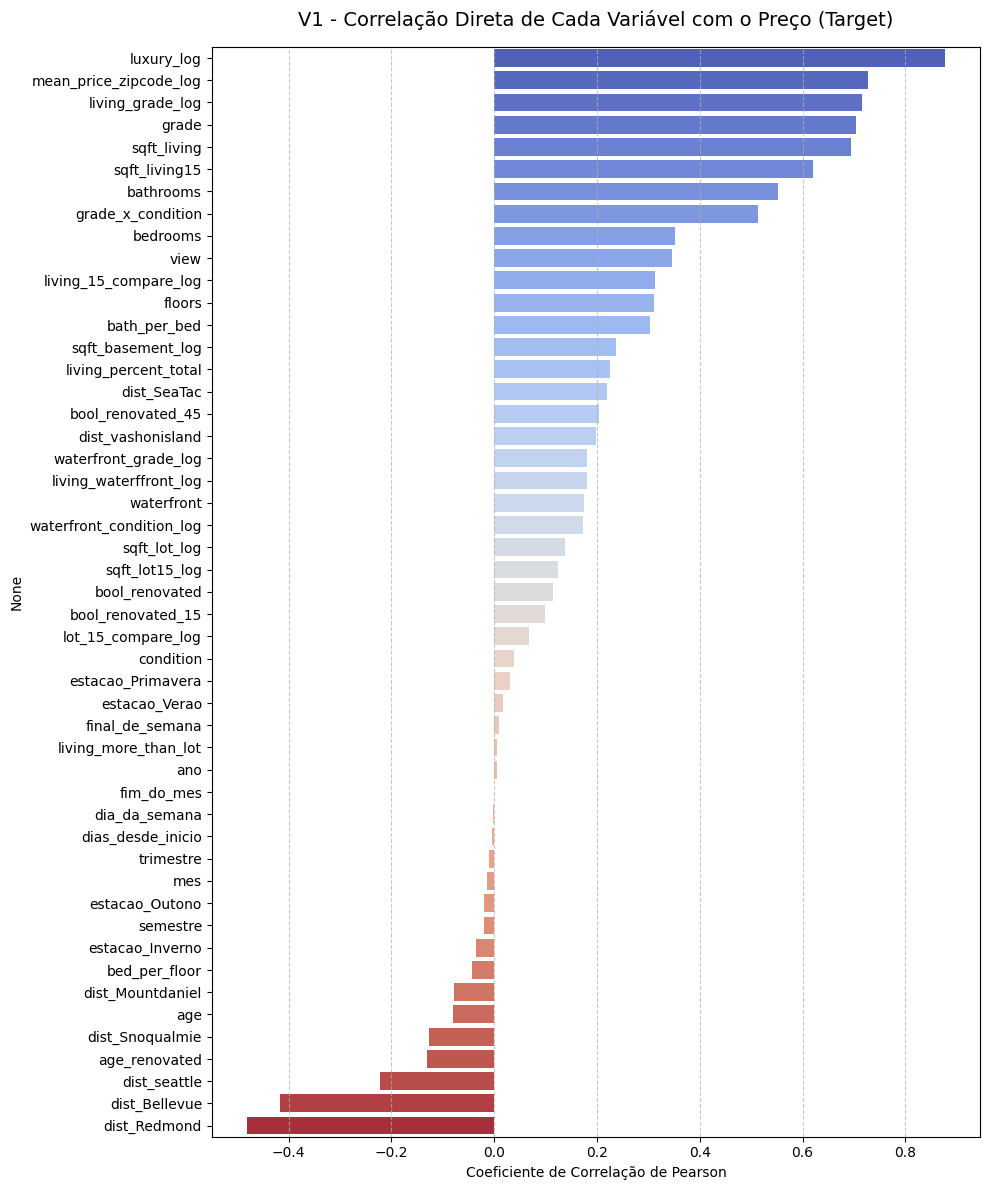

In [88]:
# Correlação V2
price_corr = df_heatmap.corr()['price_log'].sort_values(ascending=False).drop('price_log')

plt.figure(figsize=(10, 12))

sns.barplot(
    x=price_corr.values, 
    y=price_corr.index, 
    hue=price_corr.index, 
    palette='coolwarm', 
    legend=False
)

plt.title('V1 - Correlação Direta de Cada Variável com o Preço (Target)', fontsize=14, pad=15)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()